**Embedding network learned summaries vs known optimal summaries**

Date: 7.27 \
This notebook is to correct for some of the codes from week 3, comparing network learned summaries and known optimal summaries. I will be experimenting more on dimension sensitivities of each experiment, updating analysis methods for the different embedding dimensionalities (especially for cosine simularities, the output learned summaries must have the same dimensionality as optimal summaries). \
Experiments:
- 1D Gaussian with known variance, learned mean
- 2D Gaussian with known mean, learned covariance matrix
- 1D Poisson with learned rate
- 1D Exponential with learned scale


Previously with 1D Gaussian and embedding dimensions > 1, the cosine simularities were not close to +-1, and for the later exponential case it even exceeded -1. This problem possibly arised from the optimal summary tensor not having the same dimensionality as learned summaries, the following cell corrects for this mismatch.

In [1]:
# SETUP 
import torch
from sbi import utils as utils
from sbi.inference import simulate_for_sbi
from sbi.utils.user_input_checks import prepare_for_sbi
from sbi.inference import SNPE
import matplotlib.pyplot as plt
import numpy as np
from sbi.neural_nets import posterior_nn
import torch.nn as nn
import torch.nn.functional as F
torch.random.manual_seed(13)

# 1D Gaussian
# parameters
dim = 1
n_obs = 10000
prior = torch.distributions.Normal(loc=torch.zeros(dim), scale=torch.ones(dim) * 0.05)
sim_sd = torch.ones(dim) * 0.1

# simulator 
def simulator(theta):
    return torch.normal(theta, sim_sd).expand(-1,n_obs)

# embedding network
class embedding_network(nn.Module):
    def __init__(self, input_dim, embedding_dim):
        super().__init__()
        self.network = nn.Sequential(    #sets up a sequential learning network with Linear + ReLU + Linear layers
            nn.Linear(input_dim, 64),   # input dimension --> 64D
            nn.ReLU(),
            nn.Linear(64, embedding_dim)   # 64D --> output dimension
        )

    def forward(self, x):
        return self.network(x)

# training sbi, regular training method
def train_sbi(net, num_simulations, prior):
    sim, pri = prepare_for_sbi(simulator, prior)
    theta, x = simulate_for_sbi(sim, pri, num_simulations=num_simulations)
    x = x.view(x.shape[0], -1)  # reshape x

    nn_estimator = posterior_nn(model='maf', embedding_net=net)
    inference = SNPE(prior=pri, density_estimator=nn_estimator)
    de = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(de)

    return posterior, net, theta, x

# analysis, extract learned summary stats
class analyze_embeddings:
    def __init__(self, embedding_net, x_eval, optimal_summary):
        self.embedding_net = embedding_net
        self.eval_x = x_eval
        self.optimal_summary = optimal_summary
        self.analyze()

    def analyze(self):
        learned_summary = self.embedding_net(self.eval_x)
        optimal_summary = self.optimal_summary(self.eval_x)

        self.learned_summary = learned_summary
        self.optimal_summary = optimal_summary

    # project learned summary to 1D, compare the first column component only
        projected_learned = learned_summary[:, 0:1]
        self.projected_learned = projected_learned

    # cosine similarity
        learned_norm = F.normalize(projected_learned, dim=1)
        optimal_norm = F.normalize(optimal_summary, dim=1)
        cosine_sim = torch.sum(learned_norm * optimal_norm, dim=1).mean().item()

    # pearson correlation
        corr = torch.corrcoef(torch.stack([
        projected_learned.squeeze(),
        optimal_summary.squeeze()
        ]))[0, 1].item()

        print(f"Cosine similarity: {cosine_sim:.4f}")
        print(f"Pearson correlation: {corr:.4f}")

        self.cosine_similarity = cosine_sim
        self.correlation = corr

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.



Training with embedding_dim = 1


C:\Users\boat\AppData\Local\Temp\ipykernel_7156\4144513000.py:40: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator, prior)


  0%|          | 0/10000 [00:00<?, ?it/s]

c:\Users\boat\anaconda3\envs\sbi-features\lib\site-packages\sbi\neural_nets\net_builders\flow.py:141: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 36 epochs.Cosine similarity: -0.9800
Pearson correlation: -0.9892

Training with embedding_dim = 2


...

 Neural network successfully converged after 62 epochs.Cosine similarity: 0.9400
Pearson correlation: 0.9766

Training with embedding_dim = 4


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 121 epochs.Cosine similarity: -1.0000
Pearson correlation: -0.9619

Training with embedding_dim = 8


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 40 epochs.Cosine similarity: 0.1600
Pearson correlation: 0.8224


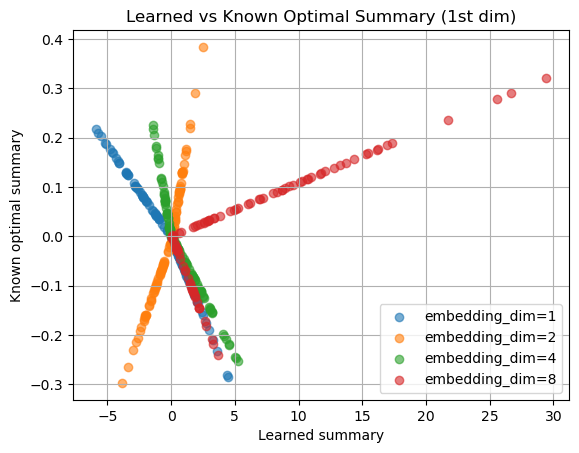

{1: {'cosine_similarity': -0.9800000190734863,
  'correlation': -0.9892263412475586},
 2: {'cosine_similarity': 0.9399999976158142,
  'correlation': 0.9766041040420532},
 4: {'cosine_similarity': -1.0, 'correlation': -0.9619131088256836},
 8: {'cosine_similarity': 0.1599999964237213,
  'correlation': 0.8223519325256348}}

In [2]:
# experiment
def gaussian_mean_experiment():
    def optimal_summary(x):
        return x.mean(dim=1, keepdim=True)

    embedding_dims = [1, 2, 4, 8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\nTraining with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs, prior=prior)

        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

        # visualise just the first component of the summaries
        learned = analysis.learned_summary.detach()[:, 0]
        known = analysis.optimal_summary.detach()[:, 0]

        plt.scatter(
            learned.numpy(),
            known.numpy(),
            alpha=0.6,
            label=f"embedding_dim={dim_embed}"
        )

    plt.xlabel("Learned summary")
    plt.ylabel("Known optimal summary")
    plt.title("Learned vs Known Optimal Summary (1st dim)")
    plt.grid(True)
    plt.legend()
    plt.show()

    return results

gaussian_mean_experiment()


Comparing with the previous algo, sampled x from training_sbi is no longer flattened in the analyze function, to make sure learned_summary and optimal_summary have inputs of the same dimension. Then once learned_summary is learned, it is projected to the same dimensionality as optimal_summary, specifically I compared the first component of learned_summary to optimal_summary. \
This worked well for 1-4D but both metrics dropped for 8D, possibly due to the use of first column in generating cos-simularity, i.e. the optimal summary for 8D could be encoded in some other columns. This can possibly be improved via taking the column of learned_summary that gives max. cos-simularity and/or correlation coefficient.

In [ ]:
# 2D - known mean, learned covariance 
import torch
import torch.nn as nn
import torch.nn.functional as F
from sbi import utils as utils
from sbi.inference import SNPE, simulate_for_sbi
from sbi.neural_nets import posterior_nn
from sbi.utils.user_input_checks import prepare_for_sbi
torch.manual_seed(13)

# parameter + function defining
dim = 2
n_obs = 5000

# use a flat prior between -2 and 2 instead of inverse wishart
# prior needs to have dof=3 as the covariance matrix has dof=3
prior_2d = utils.BoxUniform(low=0.0*torch.ones(3), high=2*torch.ones(3))

x_mean = torch.zeros(dim, dtype=torch.float32)   #known mean

# simulator for 2D
def simulator(params):
    if params.ndim == 1:
        params = params.unsqueeze(0)    # to avoid iteration over 0D tensor

    samples = []
    for i in range(params.shape[0]):
        var1, covar, var2 = params[i]   # to generate cov matrix components

        # ensure positive definiteness
        max_tries = 10
        tries = 0
        # if the sampled matrix is not positive definite, generate it from random until it is pos-def
        while var1 * var2 <= covar ** 2:
            var1 = torch.rand(1).item() * 2
            var2 = torch.rand(1).item() * 2
            covar = torch.rand(1).item() * 2 - 1  # allow negative covariances
            tries += 1
            if tries > max_tries:
                # identity covariance
                var1, var2, covar = 1.0, 1.0, 0.0
                break

        cov_matrix = torch.tensor([[var1, covar], [covar, var2]])
        dist = torch.distributions.MultivariateNormal(loc=x_mean, covariance_matrix=cov_matrix)
        samples.append(dist.sample((n_obs,)).flatten())

    return torch.stack(samples)

# embedding network
class embedding_network(nn.Module):
    def __init__(self, input_dim, embedding_dim):
        super().__init__()
        self.network = nn.Sequential(    #sets up a sequential learning network with Linear + ReLU + Linear layers
            nn.Linear(input_dim, 64),   # input dimension --> 64D
            nn.ReLU(),
            nn.Linear(64, embedding_dim)   # 64D --> output dimension
        )

    def forward(self, x):
        return self.network(x)

# training sbi
def train_sbi(net, num_simulations, prior):
    sim, pri = prepare_for_sbi(simulator, prior)
    theta, x = simulate_for_sbi(sim, pri, num_simulations=num_simulations)
    x = x.view(x.shape[0], -1)  # reshape x

    nn_estimator = posterior_nn(model='maf', embedding_net=net)
    inference = SNPE(prior=pri, density_estimator=nn_estimator)
    de = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(de)

    return posterior, net, theta, x

# analysis, extract learned summary stats
class analyze_embeddings:
    def __init__(self, embedding_net, x_eval, optimal_summary):
        self.embedding_net = embedding_net
        self.eval_x = x_eval
        self.optimal_summary = optimal_summary
        self.analyze()

    def analyze(self):
        learned_summary = self.embedding_net(self.eval_x)  # (batch, embedding_dim)
        optimal_summary = self.optimal_summary(self.eval_x)  # (batch, 4)

        self.learned_summary = learned_summary
        self.optimal_summary = optimal_summary

        # project learned_summary to shape matching optimal_summary (4D)
        projection = nn.Linear(learned_summary.shape[1], optimal_summary.shape[1])
        projected_learned = projection(learned_summary)  # (batch, 4)

        # cosine similarity
        learned_norm = F.normalize(projected_learned, dim=1)
        optimal_norm = F.normalize(optimal_summary, dim=1)
        cosine_sim = torch.sum(learned_norm * optimal_norm, dim=1).mean().item()

        # correlation
        corr = torch.corrcoef(torch.stack([
            projected_learned[:, 0],
            optimal_summary[:, 0]
        ]))[0, 1].item()

        print(f"Cosine similarity: {cosine_sim:.4f}")
        print(f"Pearson correlation: {corr:.4f}")

        self.cosine_similarity = cosine_sim
        self.correlation = corr

# create cov matrix
def optimal_summary(x):
    batch_size = x.shape[0]
    x = x.view(batch_size, n_obs, dim)
    summaries = []
    for i in range(batch_size):
        centered = x[i] - x[i].mean(dim=0)
        cov = centered.T @ centered / (n_obs - 1)   # gives 2x2 cov matrix from [dim, n_obs] * [n_obs, dim]
        summary = torch.tensor([cov[0, 0], cov[0, 1], cov[1, 1]])  # flatten
        summaries.append(summary)
    return torch.stack(summaries)[:, 1:2]  # take only cov[0,1], the covariance between two dims

# experiment
def gaussian_2D_covariance_experiment():
    embedding_dims = [1, 2, 4, 8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs * dim, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs, prior=prior_2d)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

gaussian_2D_covariance_experiment()

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.



 Training with embedding_dim = 1


C:\Users\boat\AppData\Local\Temp\ipykernel_6892\1696810566.py:65: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator, prior)


  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 23 epochs.Cosine similarity: -0.1600
Pearson correlation: -0.0562

 Training with embedding_dim = 2


...

  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 23 epochs.Cosine similarity: -0.1000
Pearson correlation: -0.3738

 Training with embedding_dim = 8


  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 23 epochs.Cosine similarity: -0.1000
Pearson correlation: 0.3250


{1: {'cosine_similarity': -0.1599999964237213,
  'correlation': -0.05622643232345581},
 2: {'cosine_similarity': -0.30000001192092896,
  'correlation': -0.24425886571407318},
 4: {'cosine_similarity': -0.10000000149011612,
  'correlation': -0.3737829327583313},
 8: {'cosine_similarity': -0.10000000149011612,
  'correlation': 0.3250436782836914}}

For 2D Gaussian case, the summary to be learned is now 4D (cov matrix is 2x2), therefore the linear metrics would not work so well in this case. With n_obs = 1000, the training gave cos-simularity very close to 0 and correlation below 0.5, which could indicate the training was not sufficient, therefore n_obs was increased by 5x. \
Since the input dimension is very high (n_obs * dim) and embedding dimensions are very low ({1,2,4,8}), this could lead to some information loss over the network layers, so worth trying increasing output dim or adding more layers of higher dimensions.

In [2]:
# still 2D Gaussian with network learning covariance matrix, but with more layers in embedding network

class embedding_network_run2(nn.Module):
    def __init__(self, input_dim, embedding_dim):
        super().__init__()
        self.network = nn.Sequential(    #sets up a sequential learning network with Linear + ReLU + Linear layers
            nn.Linear(input_dim, 128),   # input dimension --> 128D
            nn.ReLU(),
            nn.Linear(128, 64),   # 128 --> 64D
            nn.ReLU(),
            nn.Linear(64, embedding_dim)   # 64 --> embedding_dim
            # here i'm trying to see if a more gradual decrease in dimensionality of summaries will contribute to a better linearity
        )

    def forward(self, x):
        return self.network(x)

# run2 with all the same setups except for the network used
def gaussian_2D_cov_run2():
    embedding_dims = [1, 2, 4, 8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network_run2(input_dim=n_obs * dim, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs, prior=prior_2d)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

gaussian_2D_cov_run2()


 Training with embedding_dim = 1


C:\Users\boat\AppData\Local\Temp\ipykernel_6892\1696810566.py:65: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator, prior)


  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 23 epochs.Cosine similarity: -0.3800
Pearson correlation: -0.1418

 Training with embedding_dim = 2


  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 23 epochs.Cosine similarity: -0.4600
Pearson correlation: -0.1841

 Training with embedding_dim = 8


  0%|          | 0/5000 [00:00<?, ?it/s]

 Neural network successfully converged after 24 epochs.Cosine similarity: 0.0600
Pearson correlation: 0.0998


{1: {'cosine_similarity': -0.3799999952316284,
  'correlation': -0.14178484678268433},
 2: {'cosine_similarity': 0.5400000214576721,
  'correlation': -0.15818369388580322},
 4: {'cosine_similarity': -0.46000000834465027,
  'correlation': -0.18408149480819702},
 8: {'cosine_similarity': 0.05999999865889549,
  'correlation': 0.09981010109186172}}

With two more layers and deeper learning network, the cosine simularity and correlation coefficients improve (closer to +-1) from previous results, although 8D is an exception. This means for embedding_dim = {1,2,4} the deeper network contributed to a better alignment of first components to the optimal summary, but for 8D some other components may align better with, hence is a better representation of, the optimal summary. I would expect with even higher embedding_dim, the alignment of first component with optimal summary becomes even worse since the network is able to learn more complex structures and encode features in a wider spread of dims.

In [3]:
# Poisson
from sbi import utils
torch.manual_seed(13)

dim = 1
n_obs = 10000
prior_poisson = utils.BoxUniform(low=torch.tensor([0.0]), high=torch.tensor([5.0]))   #uniform prior for lambda (rate)


def simulator_poisson(rate):
    return torch.poisson(rate.expand(n_obs))


def train_sbi(net, num_simulations=n_obs):
    sim, pri = prepare_for_sbi(simulator_poisson, prior_poisson)
    theta, x = simulate_for_sbi(sim, pri, num_simulations=num_simulations)
    x = x.view(x.shape[0], -1)  #reshape x

    nn_estimator = posterior_nn(model='maf', embedding_net=net)
    inference = SNPE(prior=pri, density_estimator=nn_estimator)
    de = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(de)

    return posterior, net, theta, x

def poisson_rate_experiment():
    def optimal_summary(x):
        return x.sum(dim=dim, keepdim=True)    #summary stats = sum(x) for Poisson

    embedding_dims = [1, 2, 4, 8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

poisson_rate_experiment()


 Training with embedding_dim = 1


C:\Users\boat\AppData\Local\Temp\ipykernel_6892\3089030681.py:15: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator_poisson, prior_poisson)


  0%|          | 0/10000 [00:00<?, ?it/s]

c:\Users\boat\anaconda3\envs\sbi-features\lib\site-packages\sbi\neural_nets\net_builders\flow.py:141: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 57 epochs.Cosine similarity: -1.0000
Pearson correlation: -0.9999

 Training with embedding_dim = 2


...

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 51 epochs.Cosine similarity: 0.9600
Pearson correlation: 0.9999

 Training with embedding_dim = 8


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 65 epochs.Cosine similarity: -1.0000
Pearson correlation: -0.9998


{1: {'cosine_similarity': -1.0, 'correlation': -0.9998772740364075},
 2: {'cosine_similarity': 0.9800000190734863,
  'correlation': 0.9997643232345581},
 4: {'cosine_similarity': 0.9599999785423279,
  'correlation': 0.9998942613601685},
 8: {'cosine_similarity': -1.0, 'correlation': -0.9998303651809692}}

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sbi import utils as utils
from sbi.inference import SNPE, simulate_for_sbi
from sbi.neural_nets import posterior_nn
from sbi.utils.user_input_checks import prepare_for_sbi
torch.manual_seed(13)

#Exponential
n_obs = 10000
dim = 1
prior_exp = utils.BoxUniform(low=torch.tensor([0.1]), high=torch.tensor([5.0]))    #uniform prior for lambda (scale)


def simulator_exp(rate):
    return torch.distributions.Exponential(rate).sample((n_obs,))

def train_sbi(net, num_simulations=n_obs):
    sim, pri = prepare_for_sbi(simulator_exp, prior_exp)
    theta, x = simulate_for_sbi(sim, pri, num_simulations=num_simulations)
    x = x.view(x.shape[0], -1)  #reshape x

    nn_estimator = posterior_nn(model='maf', embedding_net=net)
    inference = SNPE(prior=pri, density_estimator=nn_estimator)
    de = inference.append_simulations(theta, x).train()
    posterior = inference.build_posterior(de)

    return posterior, net, theta, x

def exp_rate_experiment():
    def optimal_summary(x):
        return x.sum(dim=dim, keepdim=True)        #sumamry stats = sum(samples)

    embedding_dims = [1, 2, 4, 8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

exp_rate_experiment()


 Training with embedding_dim = 1


C:\Users\boat\AppData\Local\Temp\ipykernel_6892\761955837.py:20: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator_exp, prior_exp)


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 49 epochs.Cosine similarity: 1.0000
Pearson correlation: 0.9999

 Training with embedding_dim = 2


  0%|          | 0/10000 [00:00<?, ?it/s]

...

  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 52 epochs.Cosine similarity: 1.0000
Pearson correlation: 0.9970

 Training with embedding_dim = 8


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 59 epochs.Cosine similarity: -0.1200
Pearson correlation: 0.8179


{1: {'cosine_similarity': 1.0, 'correlation': 0.9998910427093506},
 2: {'cosine_similarity': -0.9800000190734863,
  'correlation': -0.8977465033531189},
 4: {'cosine_similarity': 1.0, 'correlation': 0.9970318675041199},
 8: {'cosine_similarity': -0.11999999731779099,
  'correlation': 0.8178589344024658}}

For the two distributions above, the simple 3 layer network seems to encode the optimal summary quite well in the first columns of the n_obs x embedding_dim learned output, except for 8D with the exponential distribution, which I feel worth running again with the 5 layer network.

The following codes are for embedding_dim = 8:
- 5 layer network, first 100 sample points analysed
- 3 layer network, whole set of sample analysed
- 3 layer network, first 100 points analysed (same as in previous code but gave different results)
Here I wanted to show that the 5 layer network outputting 8D summaries has a higher capacity of extracting the summaries than the 3 layer one, and more sample being analysed should give a smaller noise and higher scores of the two mectrics. These were indeed observed although the changes in metric scores are not very significant, however an incosistency was observed for the last cell, where the exact same algo was ran for 8D only (so instead of looping over {1,2,4,8}D I only kept 8D), which gave a high metric score, distinct from the previous cell's results. In my opinion this difference is way too significant to have come from the stochastic nature of simulated data?

In [5]:
# Exponential 8D with embedding_network_run2 (5 layer network)

def exp_rate_8Drun2():
    def optimal_summary(x):
        return x.sum(dim=dim, keepdim=True)        #sumamry stats = sum(samples)

    embedding_dims = [8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network_run2(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

exp_rate_8Drun2()


 Training with embedding_dim = 8


C:\Users\boat\AppData\Local\Temp\ipykernel_6892\761955837.py:20: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator_exp, prior_exp)


  0%|          | 0/10000 [00:00<?, ?it/s]

c:\Users\boat\anaconda3\envs\sbi-features\lib\site-packages\sbi\neural_nets\net_builders\flow.py:141: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 72 epochs.Cosine similarity: 1.0000
Pearson correlation: 0.9995


{8: {'cosine_similarity': 1.0, 'correlation': 0.9994646310806274}}

In [6]:
# still exponential with 8D but analysing the entire set of x instead of first 100
def exp_rate_experiment():
    def optimal_summary(x):
        return x.sum(dim=dim, keepdim=True)        #sumamry stats = sum(samples)

    embedding_dims = [8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs)
        analysis = analyze_embeddings(net, x, optimal_summary)   #now analysing whole of x instead of first 100
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

exp_rate_experiment()


 Training with embedding_dim = 8


C:\Users\boat\AppData\Local\Temp\ipykernel_6892\761955837.py:20: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator_exp, prior_exp)


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 57 epochs.Cosine similarity: 1.0000
Pearson correlation: 0.9987


{8: {'cosine_similarity': 1.0, 'correlation': 0.9986587166786194}}

In [9]:
def exp_rate_experiment():
    def optimal_summary(x):
        return x.sum(dim=dim, keepdim=True)        #sumamry stats = sum(samples)

    embedding_dims = [8]
    results = {}

    for dim_embed in embedding_dims:
        print(f"\n Training with embedding_dim = {dim_embed}")
        embed_net = embedding_network(input_dim=n_obs, embedding_dim=dim_embed)
        posterior, net, theta, x = train_sbi(embed_net, num_simulations=n_obs)
        analysis = analyze_embeddings(net, x[:100], optimal_summary)
        results[dim_embed] = {
            "cosine_similarity": analysis.cosine_similarity,
            "correlation": analysis.correlation
        }

    return results

exp_rate_experiment()


 Training with embedding_dim = 8


C:\Users\boat\AppData\Local\Temp\ipykernel_6892\761955837.py:20: DeprecationWarning: This method is deprecated as of sbi version v0.23.0. and will be removed in a         future release.Please use `process_prior` and `process_simulator` in the future.
  sim, pri = prepare_for_sbi(simulator_exp, prior_exp)


  0%|          | 0/10000 [00:00<?, ?it/s]

 Neural network successfully converged after 75 epochs.Cosine similarity: -1.0000
Pearson correlation: -0.9768


{8: {'cosine_similarity': -1.0, 'correlation': -0.9767801761627197}}